In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

Text(0, 0.5, 'y dataset')

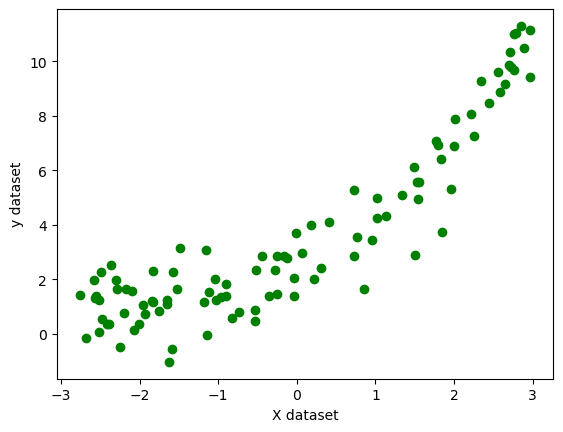

In [3]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5 *X + 2 + np.random.randn(100, 1)

plt.scatter(X, y, color = 'g')
plt.xlabel('X dataset')
plt.ylabel('y dataset')

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [6]:
X_train

array([[-2.35658655],
       [-0.52319254],
       [-0.34869602],
       [-1.82458053],
       [ 2.34681408],
       [-0.1303874 ],
       [-0.03373652],
       [ 1.49191317],
       [-2.28616541],
       [-0.82845891],
       [ 0.21246906],
       [-2.38647177],
       [ 1.96480692],
       [ 1.01567182],
       [ 2.25295945],
       [-2.16993739],
       [-0.28094494],
       [ 0.76559167],
       [ 0.41365284],
       [-1.11606127],
       [ 2.55558336],
       [-1.82226168],
       [-1.04522718],
       [-1.03293167],
       [-1.5891961 ],
       [-0.90584241],
       [ 0.85305823],
       [ 0.17711648],
       [-1.74826561],
       [-1.13782829],
       [-1.61876343],
       [ 2.57837781],
       [ 1.52738179],
       [ 2.21231941],
       [-2.564754  ],
       [-0.4433974 ],
       [-1.84399504],
       [-1.48294629],
       [ 1.84883048],
       [ 0.72628698],
       [ 1.99615468],
       [ 2.75606333],
       [ 0.95840971],
       [-1.65491356],
       [-0.52791572],
       [ 0

In [7]:
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()
regression_1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
from sklearn.metrics import r2_score

score = r2_score(y_test, regression_1.predict(X_test))
print(score)

0.7336922093901965


Text(0, 0.5, 'Y Dataset')

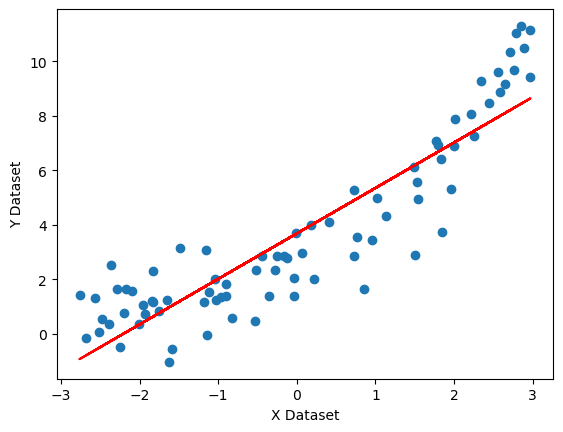

In [9]:
plt.plot(X_train, regression_1.predict(X_train), color = 'r')
plt.scatter(X_train, y_train)
plt.xlabel('X Dataset')
plt.ylabel('Y Dataset')

In [10]:
#Polynomial Regression

from sklearn.preprocessing import PolynomialFeatures

In [11]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [12]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test , y_pred)
print(score)

0.9520906154876208


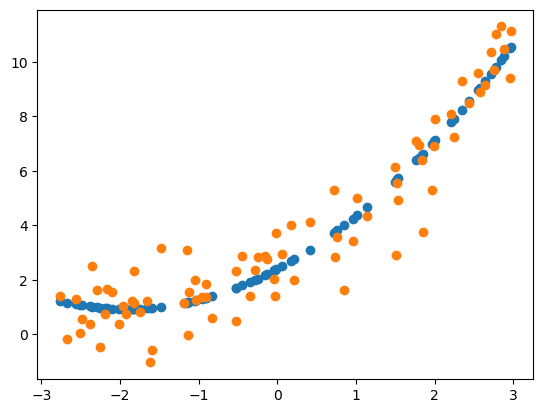

In [13]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)

In [ ]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)

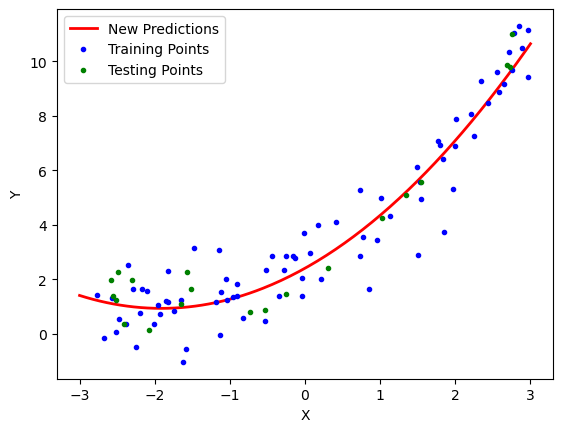

In [15]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label='New Predictions')
plt.plot(X_train, y_train, "b.", label= 'Training Points' )
plt.plot(X_test, y_test, "g.",  label='Testing Points' )
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## Pipeline Concept

In [16]:
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    poly_features = PolynomialFeatures(degree= degree, include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ("poly_features", poly_features),
        ("Lin_reg", lin_reg)
    ])

    poly_regression.fit(X_train, y_train) ## Polynomial features and fit of linear regression
    y_pred_new = poly_regression.predict(X_new)
    plt.plot(X_new, y_pred_new, 'r', label= "Degree" + str(degree), linewidth=3 )
    plt.plot(X_train, y_train, "b.", linewidth= 3 )
    plt.plot(X_test, y_test, "g." , linewidth=3)
    plt.legend(loc = "upper left")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis([-4,4,0,10])
    plt.show()

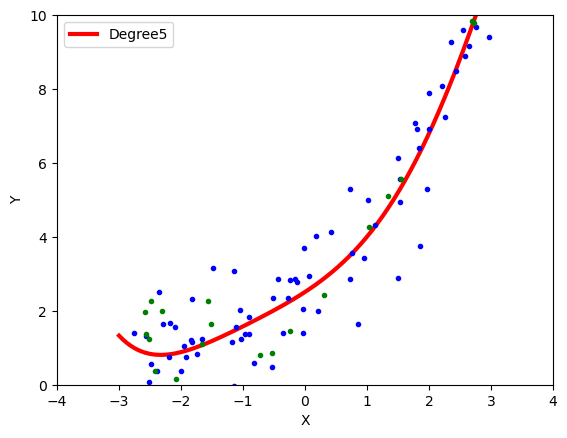

In [22]:
poly_regression(5)